# Fitting Parameters and Retrievals

Everything in the series so far — atmospheric components, forward models, cloud parameterisations, parameter files, spectral binning — was building towards this: an end-to-end atmospheric retrieval. This notebook connects the forward model to an observation via a nested-sampling optimizer and extracts a posterior over the free parameters.

The example is deliberately lightweight (a single free parameter, few live points, narrow wavelength range) so that it completes in seconds rather than hours. The same workflow scales directly to production retrievals with dozens of parameters.

This notebook covers:
1. Inspecting and modifying fitting parameters on a model.
2. Creating a synthetic observation by adding noise to the forward model.
3. Running `NestleOptimizer` and examining the posterior.

More information about fitting controls is [here](../user/taurex/fitting.rst), optimizers are [here](../user/taurex/optimizer.rst), and observations are [here](../user/taurex/observation.rst).

## Data Note

This notebook uses the opacity and CIA files set up in [Setup and opacity data](https://escience-taurex.github.io/taurex3/examples/01_setup_and_data.html). TauREx provides the software to work with these datasets; the files themselves are third-party products from [ExoMol](https://www.exomol.com) and [HITRAN](https://hitran.org/).

In [1]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import _shared

_shared = importlib.reload(_shared)
build_transmission_model = _shared.build_transmission_model

# Use a coarse setup so the documentation notebook runs quickly.
context = build_transmission_model(
    include_cia=False,
    include_rayleigh=False,
    download=False,
    nlayers=40,
 )
tm = context['tm']

## Fitting Parameters

Every TauREx component publishes the parameters that the optimizer can vary, accessible through the `fittingParameters` dictionary on the model. The exact set changes with the model composition: a `Guillot2010` temperature profile exposes different parameters than `Isothermal`, and adding a cloud contribution adds more.

Fitting parameter names, bound types, and default transformations are described in detail [here](../user/taurex/fitting.rst).

In [2]:
print('Available fitting parameters:')
for name in sorted(tm.fittingParameters.keys()):
    print(f'  {name}')

Available fitting parameters:
  CH4
  CO2
  H2O
  He_H2
  NH3
  T
  atm_max_pressure
  atm_min_pressure
  distance
  planet_distance
  planet_mass
  planet_radius
  planet_sma


Individual parameter values can be read and updated directly through the model's bracket operator.

In [3]:
print(f'Current T: {tm["T"]}')
print(f'Current H2O: {tm["H2O"]}')

# Modify a parameter
tm['T'] = 1800.0
print(f'Updated T: {tm["T"]}')

# Reset
tm['T'] = 2000.0

Current T: 2000.0
Current H2O: 0.001
Updated T: 1800.0


## A Synthetic Observation

Rather than loading real data, we generate a synthetic observation by running the forward model at known parameters and adding Gaussian scatter. This gives a dataset where the ground truth is known, making it easy to check whether the retrieval recovers the right answer.

`ArraySpectrum` wraps the perturbed flux array into an observation object the optimizer understands. Note the deliberately narrow wavelength range and low bin count — they keep the notebook fast rather than exhaustive. More information on observation objects is [here](../user/taurex/observation.rst).

In [4]:
from taurex.binning import SimpleBinner
from taurex.data.spectrum.array import ArraySpectrum

# Generate a coarse "true" spectrum for a quick retrieval demo
obs_wl = np.logspace(np.log10(1.1), np.log10(3.0), 18)
obs_wn = np.sort(10000 / obs_wl)
binner = SimpleBinner(wngrid=obs_wn)
bin_wn, bin_rprs, _, _ = binner.bin_model(tm.model(wngrid=obs_wn))
bin_wl = 10000 / bin_wn[::-1]
bin_rprs = bin_rprs[::-1]

# Add noise
rng = np.random.default_rng(42)
noise_level = 3e-5
noisy_rprs = bin_rprs + rng.normal(0, noise_level, size=bin_rprs.shape)
errors = np.full_like(bin_rprs, noise_level)

# Package as an observation (columns: wavelength, data, error)
obs_array = np.column_stack([bin_wl, noisy_rprs, errors])
obs = ArraySpectrum(spectrum=obs_array)

print(f'Synthetic observation: {len(bin_wl)} bins, noise = {noise_level:.1e}')

Synthetic observation: 18 bins, noise = 3.0e-05


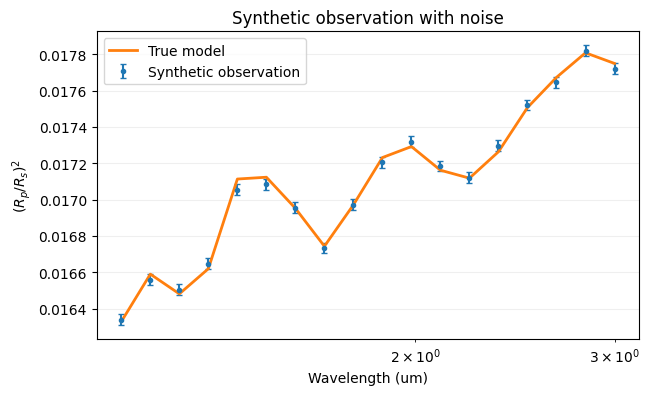

In [5]:
plt.figure(figsize=(7, 4))
plt.errorbar(obs.wavelengthGrid, obs.spectrum, obs.errorBar,
             fmt='.', capsize=2, label='Synthetic observation')
plt.plot(bin_wl, bin_rprs, lw=2, label='True model')
plt.xscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('$(R_p/R_s)^2$')
plt.title('Synthetic observation with noise')
plt.legend()
plt.grid(alpha=0.2)

## Setting Up the Retrieval

`NestleOptimizer` wraps the [nestle](http://kylebarbary.com/nestle/) nested-sampling library. Its configuration is minimal — attach a model, an observation, and declare the free parameters:
1. `set_model` — the forward model that evaluates the likelihood at each proposed point.
2. `set_observed` — the spectrum (and uncertainties) the optimizer compares against.
3. `enable_fit` + `set_boundary` — activates a fitting parameter and sets its prior range.

The live-point budget is intentionally small here. More information about optimizer options is [here](../user/taurex/optimizer.rst), and fitting-parameter syntax is [here](../user/taurex/fitting.rst).

In [6]:
from taurex.optimizer.nestle import NestleOptimizer

opt = NestleOptimizer(num_live_points=10, tol=30.0)
opt.set_model(tm)
opt.set_observed(obs)

opt.enable_fit('T')
opt.set_boundary('T', [1200, 2800])

print('Fitting parameters:')
for param in opt.fitting_parameters:
    print(f'  {param.fit_name}: bounds = {param.boundaries}')

Fitting parameters:
  T: bounds = (1200, 2800)


## Running the Sampler

Calling `fit()` launches the nested sampler. With 10 live points, a loose stopping tolerance, and a single free parameter this completes in a few seconds. The output may look noisy — that is expected from such a coarse configuration. The important point is that the full retrieval pipeline runs end-to-end.

### Retrieving composite atmospheres

Composite forward models can be retrieved in the same workflow shown here by switching the main model to `multi_transit`, `multi_eclipse`, or `multi_directimage`. In that case the regional parameter files define each atmosphere, while the shared retrieval should provide only `N-1` fraction parameters such as `fr_1`, `fr_2`, ..., `fr_{N-1}`. TauREx then infers the final region fraction automatically so the total remains normalized, alongside the region-prefixed parameters generated for uncoupled components.

In [7]:
import contextlib
import io
import taurex.log

taurex.log.disableLogging()

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    solution = opt.fit()

print('Retrieval complete.')

Retrieval complete.


## Interpreting the Posterior

`get_solution()` yields each mode of the posterior (in a simple unimodal retrieval, just one). For each solution, `update_model` sets the atmospheric parameters to the best-fit values so the corresponding spectrum can be overlaid on the data.

Post-processing quantities — altitude grids, scale heights, integrated column densities — are available as derived quantities described [here](../user/taurex/derived.rst).

Best-fit values:
  T = 1992.4940


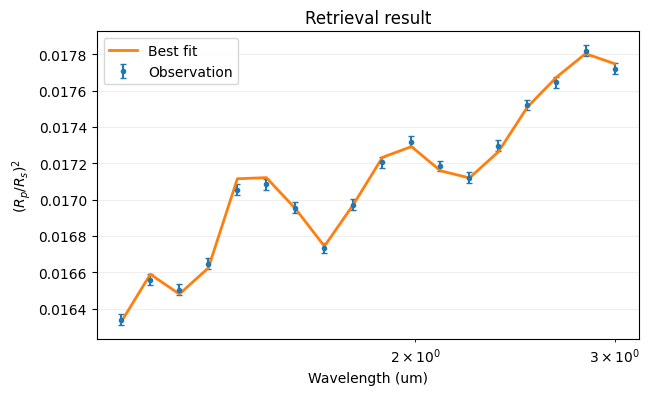

In [8]:
obs_binner = obs.create_binner()

for sol, optimized_map, optimized_value, values in opt.get_solution():
    opt.update_model(optimized_map)

    print('Best-fit values:')
    for name, value in zip(opt.fit_names, optimized_value):
        print(f'  {name} = {value:.4f}')

    fit_wn, fit_rprs, _, _ = obs_binner.bin_model(tm.model(obs.wavenumberGrid))
    fit_wl = 10000 / fit_wn[::-1]
    fit_rprs = fit_rprs[::-1]

    plt.figure(figsize=(7, 4))
    plt.errorbar(obs.wavelengthGrid, obs.spectrum, obs.errorBar,
                 fmt='.', capsize=2, label='Observation')
    plt.plot(fit_wl, fit_rprs, lw=2, label='Best fit')
    plt.xscale('log')
    plt.xlabel('Wavelength (um)')
    plt.ylabel('$(R_p/R_s)^2$')
    plt.title('Retrieval result')
    plt.legend()
    plt.grid(alpha=0.2)